# Residual-SwishNet — IQ-OTH/NCCD Lung Cancer CT (3-class)

Implementation of **Residual-SwishNet** (Nawaz, Javed & Saudagar, 2026, *Frontiers in Oncology*) — a ResNet50 backbone with every ReLU replaced by Swish, plus 3 extra dense layers before a Softmax classification head — applied to the IQ-OTH/NCCD 3-class lung CT dataset (normal / benign / malignant).

**Hyperparameters used (as requested):** LR = 5e-4, batch size = 16, epochs = 35, image size = 224x224.

This notebook includes: train/val loss & accuracy curves, validation precision/recall/F1 curves per epoch, final test-set classification report, confusion matrix (counts + normalized), and summary bar charts — all computed from scratch on this run, not copied from the paper.

**Before running:** attach the IQ-OTH/NCCD dataset to this Kaggle notebook (Add Data), so its images are visible under `/kaggle/input/...`.

## 1. Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [2]:
DATASET_NAME = "IQ-OTH/NCCD Lung Cancer CT"
MODEL_TAG = "residual_swishnet_iqothnccd"

TARGET_CLASSES = ["normal", "benign", "malignant"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4

OUTPUT_DIR = "/kaggle/working/residual_swishnet_iqothnccd"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 3. Build the train / validation / test dataframes (60/20/20 stratified split)

In [3]:
def fuzzy_map_class(folder_name):
    n = folder_name.lower()
    if "normal" in n:
        return "normal"
    if "benign" in n or "bengin" in n:  # dataset's own folder is misspelled "Bengin" in some mirrors
        return "benign"
    if "malignant" in n:
        return "malignant"
    return None

records = []
found_dirs = []
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    label = fuzzy_map_class(os.path.basename(dirpath))
    if label is None:
        continue
    image_files = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    if not image_files:
        continue
    found_dirs.append((dirpath, label, len(image_files)))
    for fname in image_files:
        records.append({"filepath": os.path.join(dirpath, fname), "label": label})

print("Matched folders:")
for d, l, n in found_dirs:
    print(f"  {d}  ->  {l}  ({n} images)")

full_pool = pd.DataFrame(records)
assert len(full_pool) > 0, "No images found -- make sure the IQ-OTH/NCCD dataset is attached under /kaggle/input"

print("\nPooled total:", len(full_pool))
print(full_pool["label"].value_counts())
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), f"({len(train_df)/len(full_pool)*100:.1f}%)")
print("Val size:  ", len(val_df), f"({len(val_df)/len(full_pool)*100:.1f}%)")
print("Test size: ", len(test_df), f"({len(test_df)/len(full_pool)*100:.1f}%)")

print("\nTrain class balance:")
print(train_df["label"].value_counts())
print("\nVal class balance:")
print(val_df["label"].value_counts())
print("\nTest class balance:")
print(test_df["label"].value_counts())


Matched folders:
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases  ->  normal  (416 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases  ->  benign  (120 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases  ->  malignant  (561 images)

Pooled total: 1097
label
malignant    561
normal       416
benign       120
Name: count, dtype: int64
Train size: 658 (60.0%)
Val size:   219 (20.0%)
Test size:  220 (20.1%)

Train class balance:
label
malignant    336
normal       250
benign        72
Name: count, dtype: int64

Val class balance:
label
malignant    112
normal        83
benign        24
Name: count, dtype: int64

Test class balance:
label
malignant    113
normal        83
benign        24
Name: count, dtype: int64


## 4. Data generators (rescale only, no augmentation)

In [4]:
# No augmentation - rescale only, for train/val/test alike
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=True, seed=42,
)
val_gen = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)
# Separate generator instance over the SAME validation data, dedicated to the
# per-epoch precision/recall/F1 callback below. Keras 3 wraps `val_gen` into
# its own internal tf.data pipeline for validation_data=val_gen during fit();
# calling .reset()/.predict() on that same generator object from inside a
# callback desyncs that pipeline and causes an empty-iterator crash
# ("OptionalFromValue... length 0") on the next epoch. Using an independent
# generator instance for the callback avoids that entirely.
val_gen_metrics = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)
test_gen = eval_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)


Found 658 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.
Found 220 validated image filenames belonging to 3 classes.


## 5. Residual-SwishNet model definition

In [5]:
def swish(x):
    """Standard Swish activation with beta fixed to 1: swish(u) = u * sigmoid(u)."""
    return tf.nn.swish(x)


def _conv_block(x, filters, stage, block, strides=2):
    """Bottleneck block WITH a projection shortcut (changes shape/channels)."""
    f1, f2, f3 = filters
    conv_name = f"conv{stage}_{block}"
    bn_name = f"bn{stage}_{block}"

    shortcut = x

    x = layers.Conv2D(f1, (1, 1), strides=strides, padding="valid", name=conv_name + "_a")(x)
    x = layers.BatchNormalization(name=bn_name + "_a")(x)
    x = layers.Activation(swish, name=conv_name + "_a_swish")(x)

    x = layers.Conv2D(f2, (3, 3), padding="same", name=conv_name + "_b")(x)
    x = layers.BatchNormalization(name=bn_name + "_b")(x)
    x = layers.Activation(swish, name=conv_name + "_b_swish")(x)

    x = layers.Conv2D(f3, (1, 1), padding="valid", name=conv_name + "_c")(x)
    x = layers.BatchNormalization(name=bn_name + "_c")(x)

    shortcut = layers.Conv2D(f3, (1, 1), strides=strides, padding="valid", name=conv_name + "_shortcut")(shortcut)
    shortcut = layers.BatchNormalization(name=bn_name + "_shortcut")(shortcut)

    x = layers.Add(name=conv_name + "_add")([x, shortcut])
    x = layers.Activation(swish, name=conv_name + "_out_swish")(x)
    return x


def _identity_block(x, filters, stage, block):
    """Bottleneck block WITHOUT a projection shortcut (identity skip connection)."""
    f1, f2, f3 = filters
    conv_name = f"conv{stage}_{block}"
    bn_name = f"bn{stage}_{block}"

    shortcut = x

    x = layers.Conv2D(f1, (1, 1), padding="valid", name=conv_name + "_a")(x)
    x = layers.BatchNormalization(name=bn_name + "_a")(x)
    x = layers.Activation(swish, name=conv_name + "_a_swish")(x)

    x = layers.Conv2D(f2, (3, 3), padding="same", name=conv_name + "_b")(x)
    x = layers.BatchNormalization(name=bn_name + "_b")(x)
    x = layers.Activation(swish, name=conv_name + "_b_swish")(x)

    x = layers.Conv2D(f3, (1, 1), padding="valid", name=conv_name + "_c")(x)
    x = layers.BatchNormalization(name=bn_name + "_c")(x)

    x = layers.Add(name=conv_name + "_add")([x, shortcut])
    x = layers.Activation(swish, name=conv_name + "_out_swish")(x)
    return x


def build_residual_swishnet(input_shape=(224, 224, 3), num_classes=4, dense_units=(1024, 512, 256)):
    """
    Residual-SwishNet (Nawaz et al. 2026): ResNet50 topology with every ReLU
    in the backbone replaced by Swish (beta fixed to 1), followed by 3 extra
    Dense(ReLU) layers and a Softmax classification layer.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Stem: 7x7, 64, stride 2 + BN + Swish + 3x3 maxpool stride 2
    x = layers.Conv2D(64, (7, 7), strides=2, padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation(swish, name="conv1_swish")(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same", name="pool1")(x)

    # Conv_L2_x: [64, 64, 256] x 3 blocks
    x = _conv_block(x, [64, 64, 256], stage=2, block="a", strides=1)
    x = _identity_block(x, [64, 64, 256], stage=2, block="b")
    x = _identity_block(x, [64, 64, 256], stage=2, block="c")

    # Conv_L3_x: [128, 128, 512] x 4 blocks
    x = _conv_block(x, [128, 128, 512], stage=3, block="a", strides=2)
    x = _identity_block(x, [128, 128, 512], stage=3, block="b")
    x = _identity_block(x, [128, 128, 512], stage=3, block="c")
    x = _identity_block(x, [128, 128, 512], stage=3, block="d")

    # Conv_L4_x: [256, 256, 1024] x 6 blocks
    x = _conv_block(x, [256, 256, 1024], stage=4, block="a", strides=2)
    x = _identity_block(x, [256, 256, 1024], stage=4, block="b")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="c")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="d")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="e")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="f")

    # Conv_L5_x: [512, 512, 2048] x 3 blocks
    x = _conv_block(x, [512, 512, 2048], stage=5, block="a", strides=2)
    x = _identity_block(x, [512, 512, 2048], stage=5, block="b")
    x = _identity_block(x, [512, 512, 2048], stage=5, block="c")

    # Average pooling
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)

    # 3 additional dense layers, ReLU activated
    x = layers.Dense(dense_units[0], activation="relu", name="dense_1")(x)
    x = layers.Dense(dense_units[1], activation="relu", name="dense_2")(x)
    x = layers.Dense(dense_units[2], activation="relu", name="dense_3")(x)

    # Softmax classification layer
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="Residual-SwishNet")
    return model


## 6. Build and compile the model

In [6]:
model = build_residual_swishnet(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


I0000 00:00:1790097629.050262      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790097629.053255      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Residual-SwishNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │      9,472 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 112, 112,  │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_swish         │ (None, 112, 112,  │          0 │ bn1[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ conv1_swish[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_a (Conv2D)  │ (None, 56, 56,    │      4,160 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_a             │ (None, 56, 56,    │        256 │ conv2_a_a[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_a_swish     │ (None, 56, 56,    │          0 │ bn2_a_a[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_b (Conv2D)  │ (None, 56, 56,    │     36,928 │ conv2_a_a_swish[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_b             │ (None, 56, 56,    │        256 │ conv2_a_b[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_b_swish     │ (None, 56, 56,    │          0 │ bn2_a_b[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_c (Conv2D)  │ (None, 56, 56,    │     16,640 │ conv2_a_b_swish[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_shortcut    │ (None, 56, 56,    │     16,640 │ pool1[0][0]       │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_c             │ (None, 56, 56,    │      1,024 │ conv2_a_c[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_shortcut      │ (None, 56, 56,    │      1,024 │ conv2_a_shortcut… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_add (Add)   │ (None, 56, 56,    │          0 │ bn2_a_c[0][0],    │
│                     │ 256)              │            │ bn2_a_shortcut[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_out_swish   │ (None, 56, 56,    │          0 │ conv2_a_add[0][0

 Total params: 26,342,787 (100.49 MB)

 Trainable params: 26,289,667 (100.29 MB)

 Non-trainable params: 53,120 (207.50 KB)

## 7. Custom callback to track precision / recall / F1 every epoch

In [7]:
class EpochMetricsCallback(tf.keras.callbacks.Callback):
    """
    Computes precision / recall / F1 (weighted average) on the validation
    set at the end of every epoch, since Keras does not track multi-class
    precision/recall/F1 out of the box the way it tracks accuracy/loss.
    Stores per-epoch values so they can be plotted alongside the standard
    accuracy/loss curves.
    """
    def __init__(self, val_generator):
        super().__init__()
        self.val_generator = val_generator
        self.val_precision = []
        self.val_recall = []
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        self.val_generator.reset()
        y_true = self.val_generator.classes
        y_pred_probs = self.model.predict(self.val_generator, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        p = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        r = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        self.val_precision.append(p)
        self.val_recall.append(r)
        self.val_f1.append(f)

        print(f" - val_precision: {p:.4f} - val_recall: {r:.4f} - val_f1: {f:.4f}")


## 8. Train the model

In [8]:
metrics_cb = EpochMetricsCallback(val_gen_metrics)

callbacks = [
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_best.keras"),
        monitor="val_loss", save_best_only=True, verbose=1,
    ),
    metrics_cb,
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/35


I0000 00:00:1790097690.696483     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.6349 - loss: 1.0501
Epoch 1: val_loss improved from None to 1.02004, saving model to /kaggle/working/residual_swishnet_iqothnccd/residual_swishnet_iqothnccd_best.keras

Epoch 1: finished saving model to /kaggle/working/residual_swishnet_iqothnccd/residual_swishnet_iqothnccd_best.keras
 - val_precision: 0.2615 - val_recall: 0.5114 - val_f1: 0.3461
42/42 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7173 - loss: 0.8330 - val_accuracy: 0.5114 - val_loss: 1.0200
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8232 - loss: 0.4933
Epoch 2: val_loss did not improve from 1.02004
 - val_precision: 0.2615 - val_recall: 0.5114 - val_f1: 0.3461
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.8359 - loss: 0.4712 - val_accuracy: 0.5114 - val_loss: 1.9722
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8419 - loss: 0.4597
Epoch 3: val_loss did not improve from 1.02004
 - val_precision: 0.2615 - val_rec

## 9. Train vs Validation — Accuracy & Loss curves

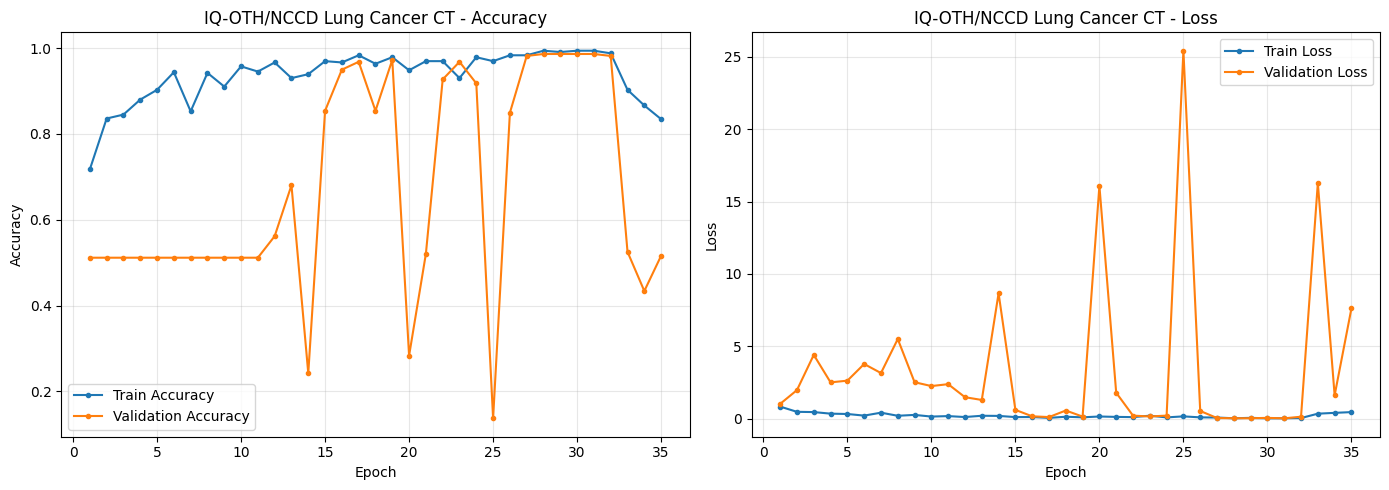

In [9]:
# Train vs Validation Accuracy and Loss curves
epochs_range = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history["accuracy"], label="Train Accuracy", marker="o", markersize=3)
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy", marker="o", markersize=3)
axes[0].set_title(f"{DATASET_NAME} - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history.history["loss"], label="Train Loss", marker="o", markersize=3)
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation Loss", marker="o", markersize=3)
axes[1].set_title(f"{DATASET_NAME} - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_loss_curves.png"), dpi=150)
plt.show()


## 10. Validation Precision / Recall / F1 curves (per epoch)

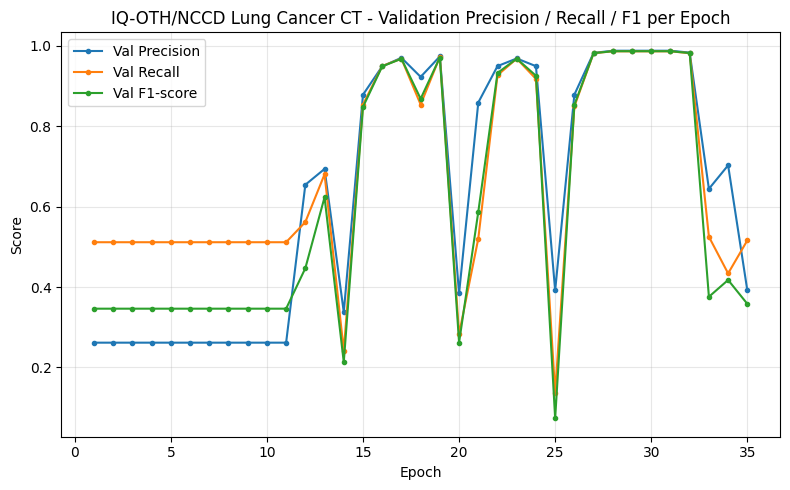

In [10]:
# Validation Precision / Recall / F1 curves across epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, metrics_cb.val_precision, label="Val Precision", marker="o", markersize=3)
plt.plot(epochs_range, metrics_cb.val_recall, label="Val Recall", marker="o", markersize=3)
plt.plot(epochs_range, metrics_cb.val_f1, label="Val F1-score", marker="o", markersize=3)
plt.title(f"{DATASET_NAME} - Validation Precision / Recall / F1 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_f1_curves.png"), dpi=150)
plt.show()


## 11. Final evaluation on the held-out TEST set

In [11]:
# Final evaluation on the held-out TEST set
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest loss: {test_loss:.4f}  |  Test accuracy: {test_acc*100:.2f}%")

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

test_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
test_accuracy_check = accuracy_score(y_true, y_pred)

print(f"\nTest Precision (weighted): {test_precision:.4f}")
print(f"Test Recall (weighted):    {test_recall:.4f}")
print(f"Test F1-score (weighted):  {test_f1:.4f}")
print(f"Test Accuracy (sklearn):   {test_accuracy_check:.4f}")

print("\nFull classification report:")
report_str = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "test_classification_report.csv"))
report_df


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.5227 - loss: 8.3348

Test loss: 8.3348  |  Test accuracy: 52.27%
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step

Test Precision (weighted): 0.6435
Test Recall (weighted):    0.5227
Test F1-score (weighted):  0.3685
Test Accuracy (sklearn):   0.5227

Full classification report:
              precision    recall  f1-score   support

      normal     1.0000    0.0241    0.0471        83
      benign     0.0000    0.0000    0.0000        24
   malignant     0.5183    1.0000    0.6828       113

    accuracy                         0.5227       220
   macro avg     0.5061    0.3414    0.2433       220
weighted avg     0.6435    0.5227    0.3685       220



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,precision,recall,f1-score,support
normal,1.000000,0.024096,0.047059,83.000000
benign,0.000000,0.000000,0.000000,24.000000
malignant,0.518349,1.000000,0.682779,113.000000
accuracy,0.522727,0.522727,0.522727,0.522727
macro avg,0.506116,0.341365,0.243279,220.000000
weighted avg,0.643515,0.522727,0.368454,220.000000


## 12. Confusion matrix (counts + row-normalized %)

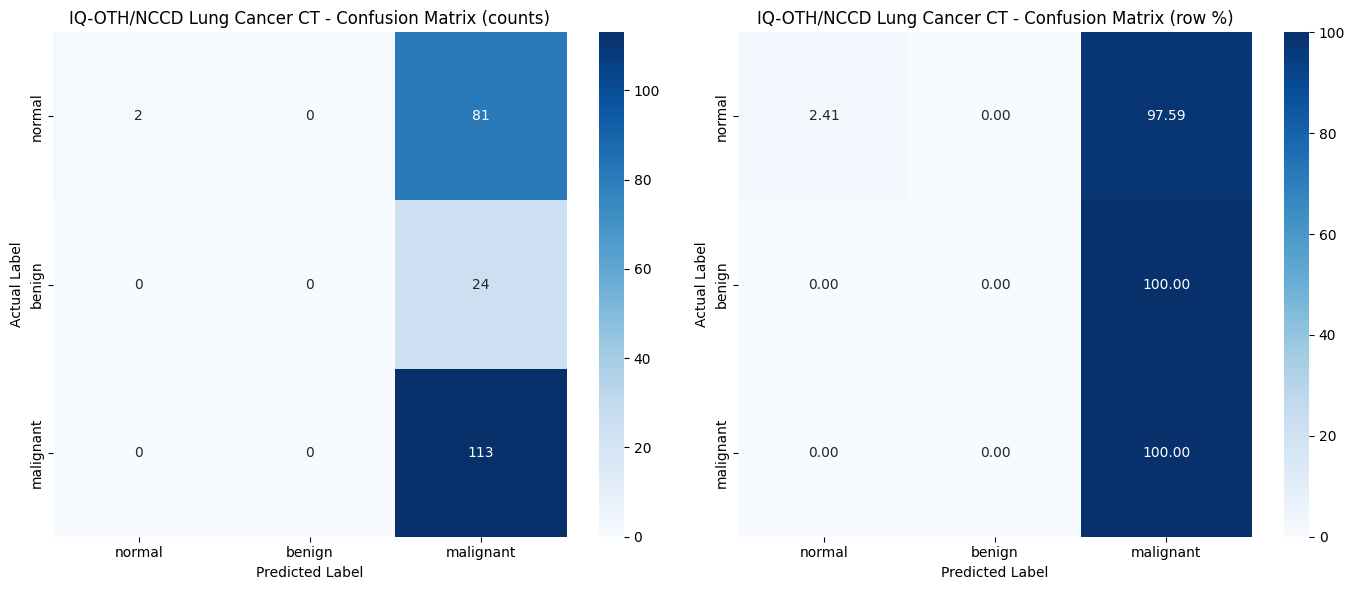

Confusion matrix (raw counts):
 [[  2   0  81]
 [  0   0  24]
 [  0   0 113]]


In [12]:
# Confusion matrix (counts) and normalized (row-percentage) confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")
axes[0].set_title(f"{DATASET_NAME} - Confusion Matrix (counts)")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")
axes[1].set_title(f"{DATASET_NAME} - Confusion Matrix (row %)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print("Confusion matrix (raw counts):\n", cm)


## 13. Summary bar charts — final test metrics & per-class metrics

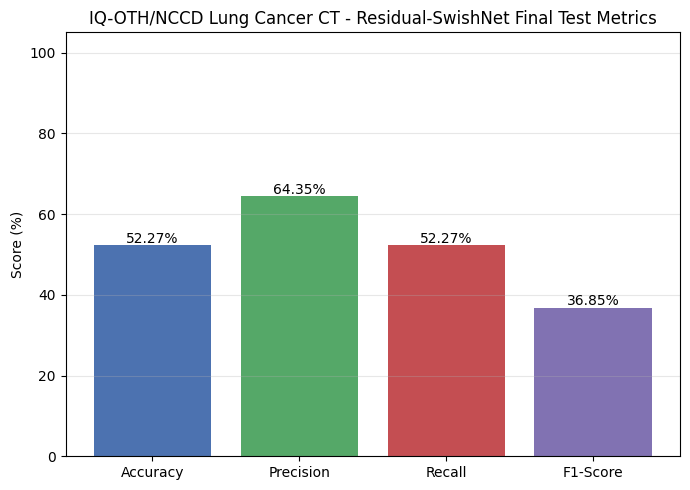

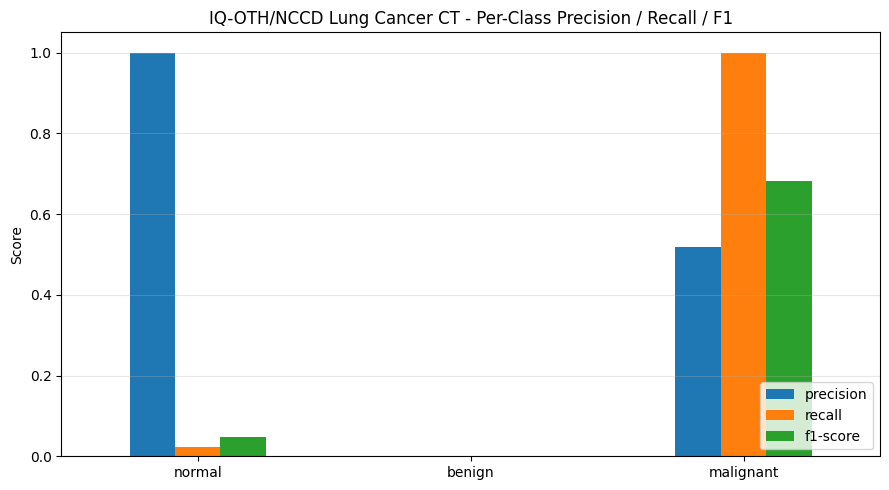

,precision,recall,f1-score
normal,1.000000,0.024096,0.047059
benign,0.000000,0.000000,0.000000
malignant,0.518349,1.000000,0.682779


In [13]:
# Bar chart summarizing final test-set Accuracy / Precision / Recall / F1
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [test_acc * 100, test_precision * 100, test_recall * 100, test_f1 * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.2f}%", ha="center", fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Score (%)")
plt.title(f"{DATASET_NAME} - Residual-SwishNet Final Test Metrics")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_metrics_bar_chart.png"), dpi=150)
plt.show()

# Per-class precision / recall / F1 bar chart
per_class_df = report_df.loc[TARGET_CLASSES, ["precision", "recall", "f1-score"]]
per_class_df.plot(kind="bar", figsize=(9, 5), rot=0)
plt.title(f"{DATASET_NAME} - Per-Class Precision / Recall / F1")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_bar_chart.png"), dpi=150)
plt.show()

per_class_df


## 14. Save model, plots, and metrics history

In [14]:
model.save(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_final.keras"))

with open(os.path.join(OUTPUT_DIR, "history.json"), "w") as f:
    json.dump({
        "train_accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_precision": metrics_cb.val_precision,
        "val_recall": metrics_cb.val_recall,
        "val_f1": metrics_cb.val_f1,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "test_precision": float(test_precision),
        "test_recall": float(test_recall),
        "test_f1": float(test_f1),
    }, f, indent=2)

print(f"Saved model, plots, and metrics history to: {OUTPUT_DIR}")


Saved model, plots, and metrics history to: /kaggle/working/residual_swishnet_iqothnccd
